In [1]:
import polars as pl

data = pl.read_parquet("../data/smoothcomp/tiny/results.parquet")

In [2]:
belts = {
    "White": 0,
    "Blue": 1,
    "Purple": 2,
    "Brown": 3,
    "Black": 4
}

absolute_df = (
    data
    .filter(pl.col("is_absolute"))
    .filter(pl.col("loser_inferred_belt").is_in(belts) & pl.col("winner_inferred_belt").is_in(belts))
    .select(pl.col("winner_inferred_belt"), pl.col("loser_inferred_belt"))
)

In [12]:
(
    data
    .filter(pl.col("is_absolute"))
    .select(pl.col("winner_inferred_belt").value_counts())
)

winner_inferred_belt
struct[2]
"{""Black"",12}"
"{""Blue"",18}"
"{""Brown"",5}"
"{"""",6}"
"{""Grey"",27}"
…
"{""White"",80}"
"{null,150}"
"{""Purple"",10}"


In [9]:
import numpy as np

num_matches_matrix = np.zeros((len(belts), len(belts)), dtype=np.int32)
higher_belt_wins_matrix = np.zeros((len(belts), len(belts)), dtype=np.float32)

for lower_belt, lower_belt_idx in belts.items():
    for higher_belt, higher_belt_idx in list(belts.items())[lower_belt_idx:]:
        lower_belt_wins = (pl.col("winner_inferred_belt") == lower_belt) & (pl.col("loser_inferred_belt") == higher_belt)
        higher_belt_wins = (pl.col("loser_inferred_belt") == lower_belt) & (pl.col("winner_inferred_belt") == higher_belt)

        curr_df = absolute_df.filter(lower_belt_wins | higher_belt_wins)
        curr_num_matches = len(curr_df)
        num_matches_matrix[higher_belt_idx, lower_belt_idx] = curr_num_matches

        if higher_belt_idx == lower_belt_idx:
            continue
        elif curr_num_matches == 0:
            higher_belt_wins_matrix[higher_belt_idx, lower_belt_idx] = -1.0
            continue
            

        num_higher_belt_wins = len(absolute_df.filter(higher_belt_wins))
        higher_belt_win_proportion = num_higher_belt_wins / curr_num_matches
        higher_belt_wins_matrix[higher_belt_idx, lower_belt_idx] = higher_belt_win_proportion

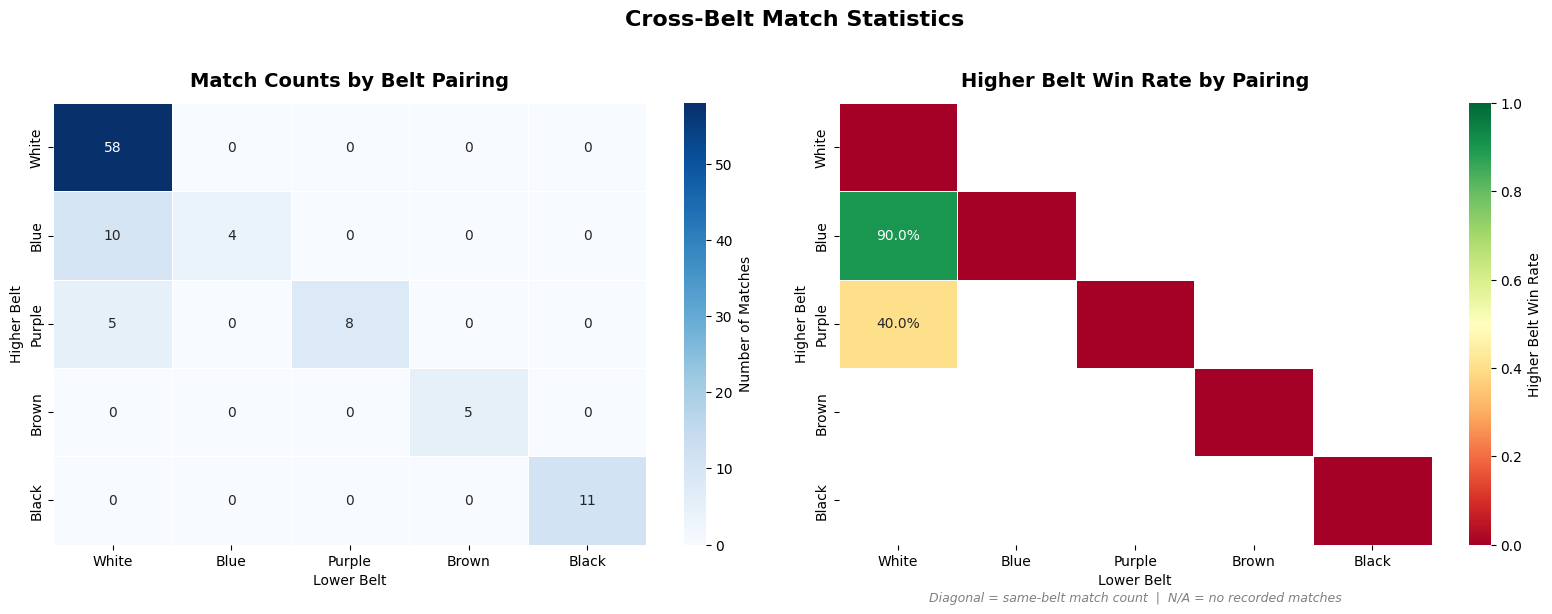

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

belt_labels = list(belts.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Match counts ---
sns.heatmap(
    num_matches_matrix,
    ax=axes[0],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=belt_labels,
    yticklabels=belt_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of Matches"},
)
axes[0].set_title("Match Counts by Belt Pairing", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Lower Belt")
axes[0].set_ylabel("Higher Belt")

# --- Win rate heatmap ---
# Mask the upper triangle (unused) and diagonal
win_rate_display = higher_belt_wins_matrix.copy()

# Build mask: upper triangle + cells where value == -1 (no data)
mask = np.triu(np.ones_like(win_rate_display, dtype=bool), k=1)
no_data_mask = win_rate_display == -1.0

# For display, set -1 cells to NaN so they render as masked
win_rate_display[no_data_mask] = np.nan

annot = np.empty_like(win_rate_display, dtype=object)
for i in range(len(belt_labels)):
    for j in range(len(belt_labels)):
        if i <= j:  # upper triangle + diagonal
            annot[i, j] = ""
        elif no_data_mask[i, j]:
            annot[i, j] = ""
        else:
            annot[i, j] = f"{win_rate_display[i, j]:.1%}"

sns.heatmap(
    win_rate_display,
    ax=axes[1],
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
    xticklabels=belt_labels,
    yticklabels=belt_labels,
    mask=mask,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Higher Belt Win Rate"},
)
axes[1].set_title("Higher Belt Win Rate by Pairing", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("Lower Belt")
axes[1].set_ylabel("Higher Belt")

# Add a small note explaining diagonal cells in win rate plot
axes[1].text(
    0.5, -0.12,
    "Diagonal = same-belt match count  |  N/A = no recorded matches",
    ha="center", va="center", transform=axes[1].transAxes,
    fontsize=9, color="gray", style="italic"
)

plt.suptitle("Cross-Belt Match Statistics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()